### Library

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

### Read Data

In [105]:
sns.set_theme(context="notebook", style="darkgrid", 
              palette="deep", font="sans-serif", font_scale=1, 
              rc={"axes.facecolor": "white"})

data_path = '..//data//ObesityDataSet_raw_and_data_sinthetic.csv'
data = pd.read_csv(data_path)

In [106]:
data.shape

(2111, 17)

### Inspect data

In [107]:
data.head(5)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [108]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [109]:
data.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


### Preprocessing data

In [110]:
# 3. Kiểm tra giá trị thiếu (missing values)
print("----- Số lượng giá trị thiếu cho từng cột -----")
data.isnull().sum()

----- Số lượng giá trị thiếu cho từng cột -----


Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

In [111]:
categorical_cols = [col for col in data.columns if data[col].dtype == 'object']
for col in categorical_cols:
    data[col] = data[col].astype('category')

print("----- Các giá trị duy nhất của các cột categorical -----")
for col in categorical_cols:
    print(f"{col}: {data[col].unique()}")
    print('-' * 50)

----- Các giá trị duy nhất của các cột categorical -----
Gender: ['Female', 'Male']
Categories (2, object): ['Female', 'Male']
--------------------------------------------------
family_history_with_overweight: ['yes', 'no']
Categories (2, object): ['no', 'yes']
--------------------------------------------------
FAVC: ['no', 'yes']
Categories (2, object): ['no', 'yes']
--------------------------------------------------
CAEC: ['Sometimes', 'Frequently', 'Always', 'no']
Categories (4, object): ['Always', 'Frequently', 'Sometimes', 'no']
--------------------------------------------------
SMOKE: ['no', 'yes']
Categories (2, object): ['no', 'yes']
--------------------------------------------------
SCC: ['no', 'yes']
Categories (2, object): ['no', 'yes']
--------------------------------------------------
CALC: ['no', 'Sometimes', 'Frequently', 'Always']
Categories (4, object): ['Always', 'Frequently', 'Sometimes', 'no']
--------------------------------------------------
MTRANS: ['Public_Trans

In [112]:
# c. Kiểm tra trùng lặp
print("----- Số lượng dòng trùng lặp -----")
print(data.duplicated().sum(), "\n")
# Nếu có dữ liệu trùng lặp, loại bỏ:
data = data.drop_duplicates()

----- Số lượng dòng trùng lặp -----
24 



### Visualize

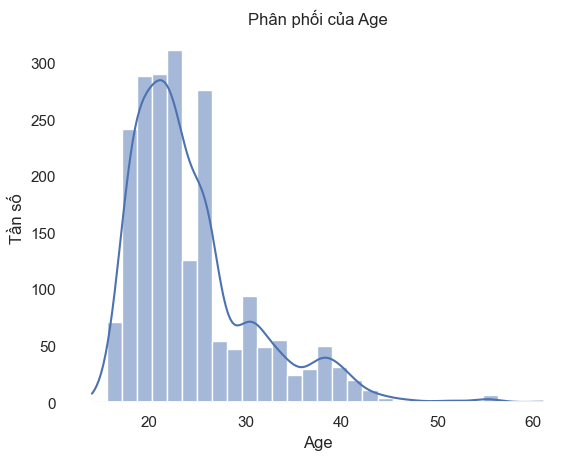

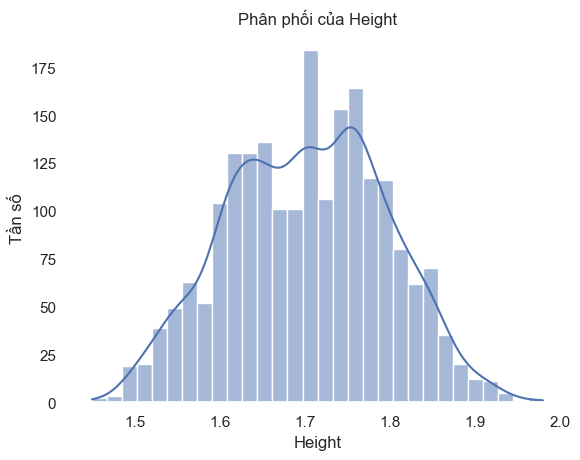

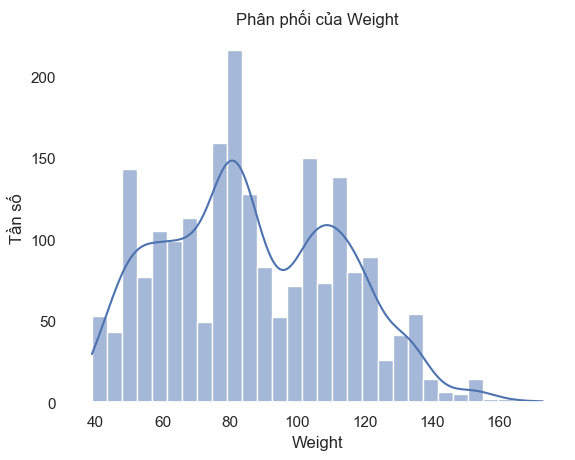

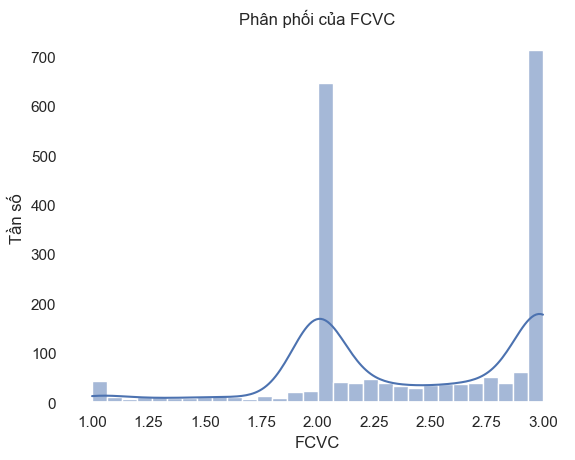

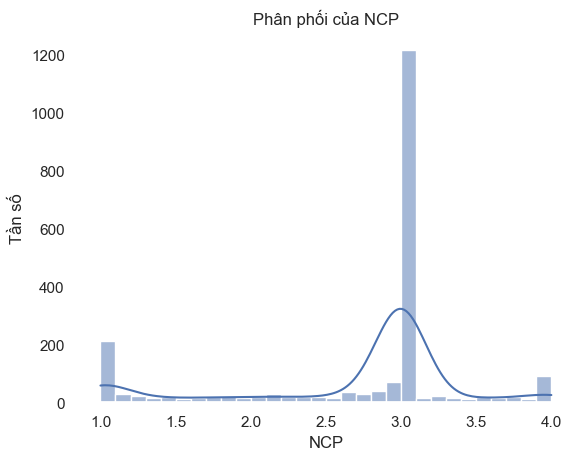

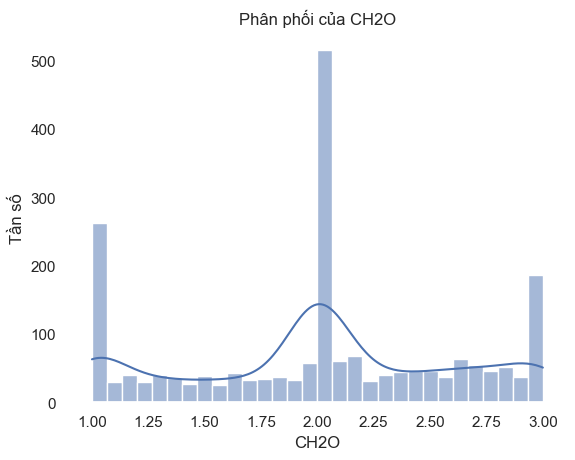

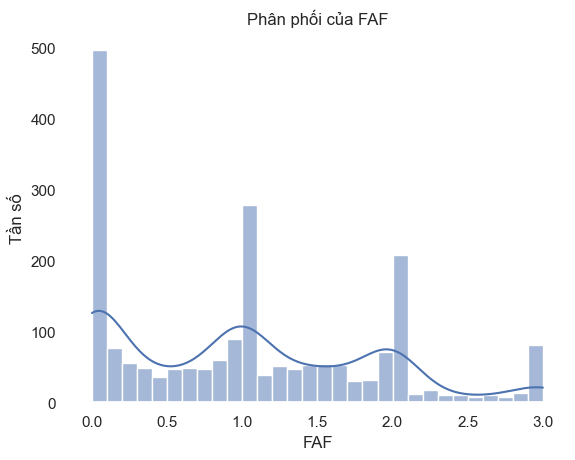

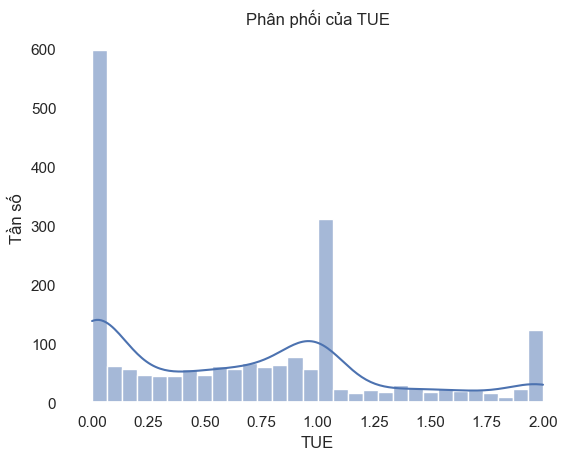

In [113]:
numerical_cols = [col for col in data.columns if data[col].dtype != 'category']
for col in numerical_cols:
    plt.figure()
    sns.histplot(data[col], kde=True, bins=30)
    plt.title(f"Phân phối của {col}")
    plt.xlabel(col)
    plt.ylabel("Tần số")
    plt.show()

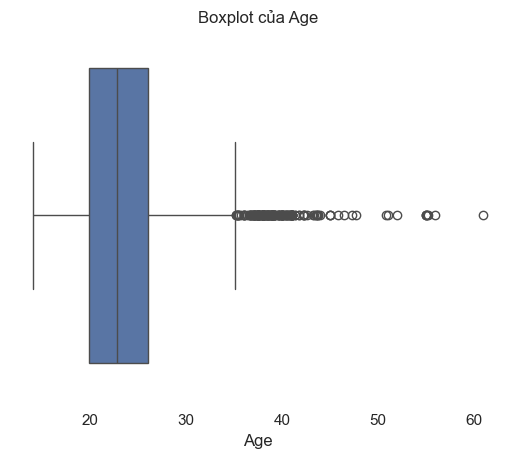

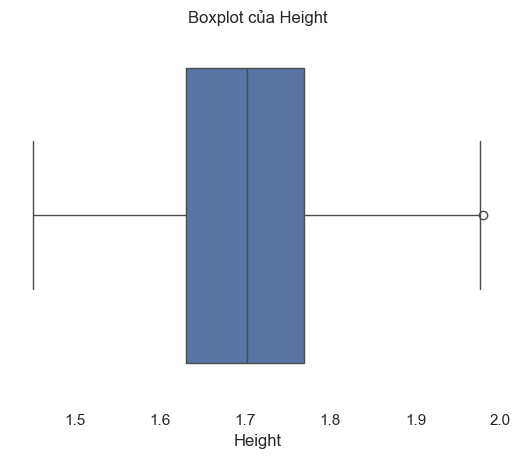

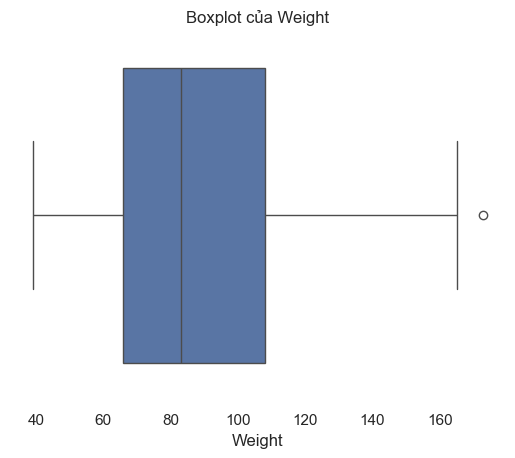

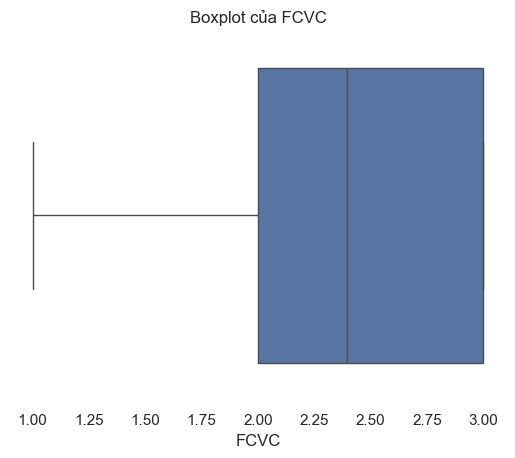

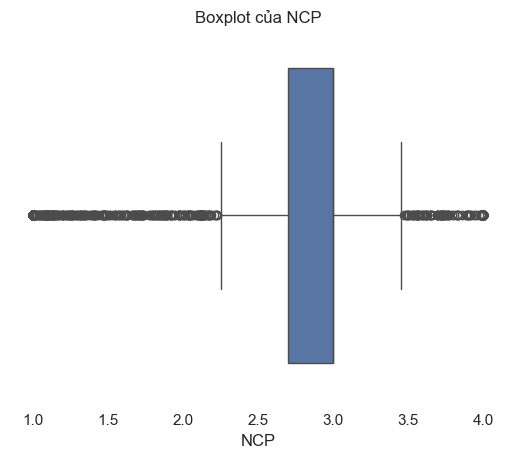

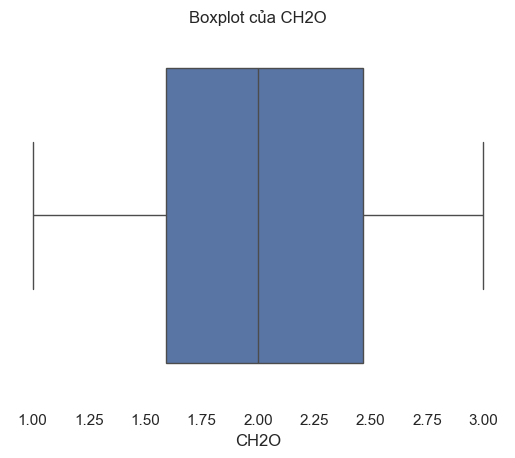

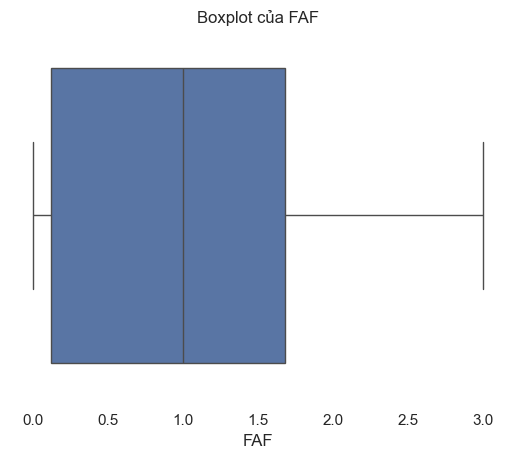

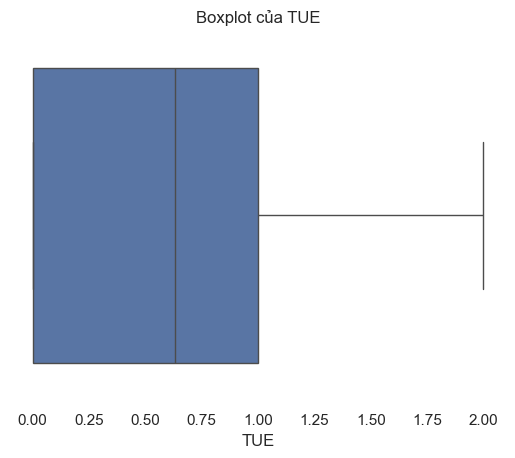

In [114]:
for col in numerical_cols:
    plt.figure()
    sns.boxplot(x=data[col])
    plt.title(f"Boxplot của {col}")
    plt.xlabel(col)
    plt.show()

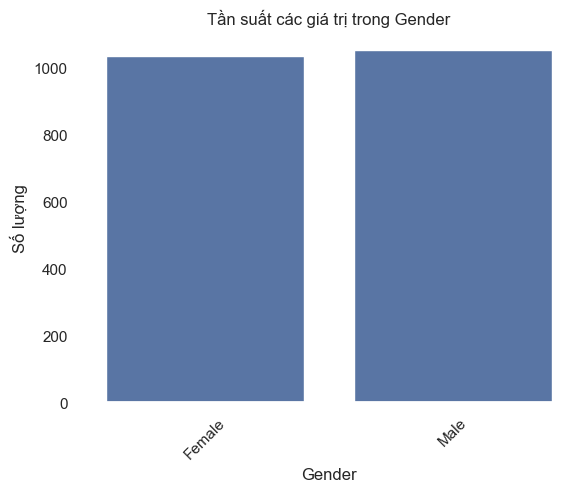

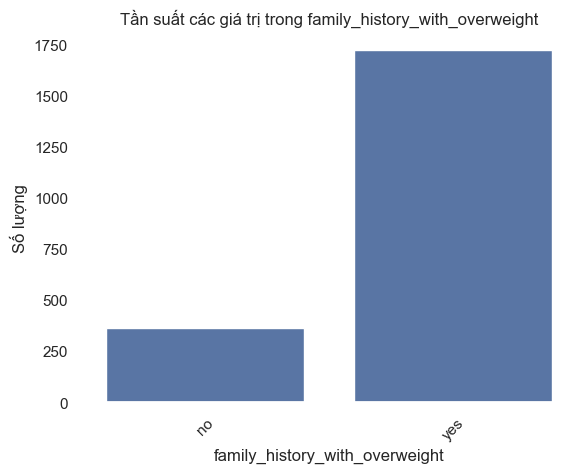

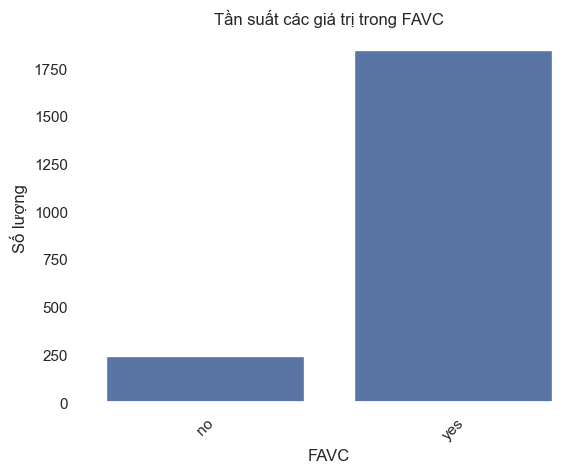

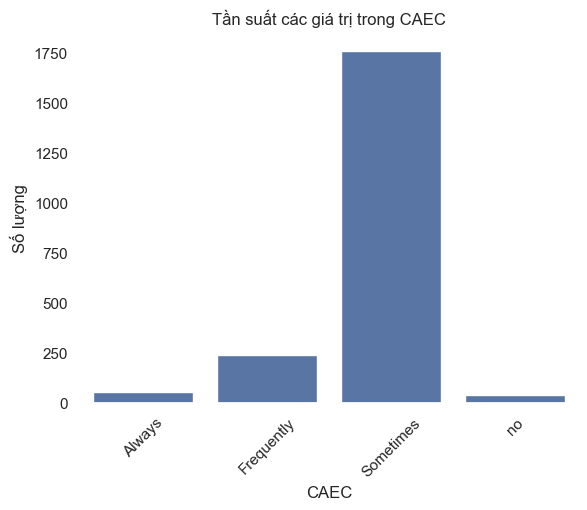

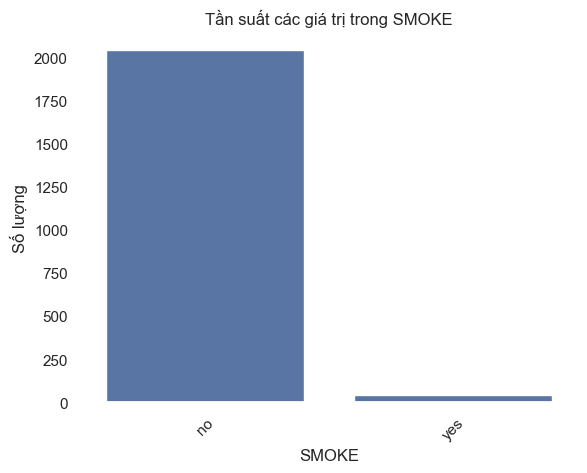

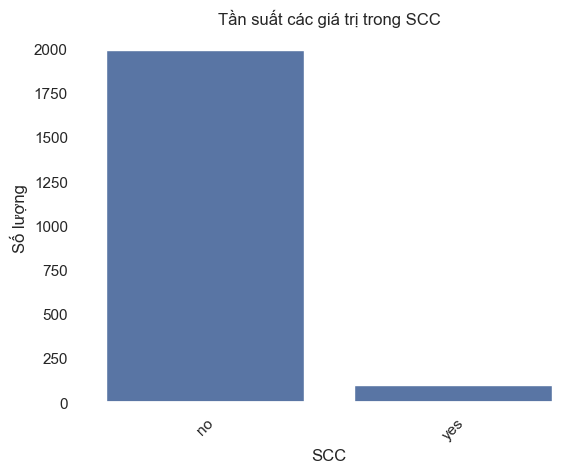

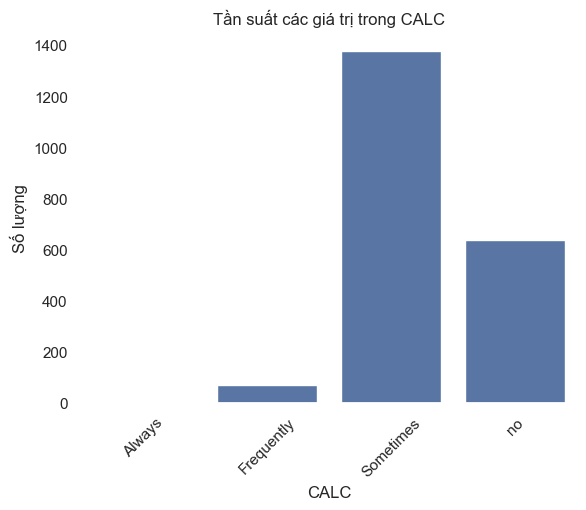

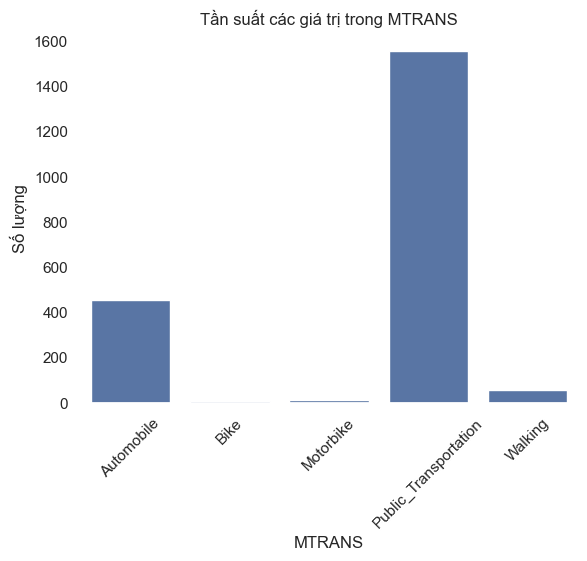

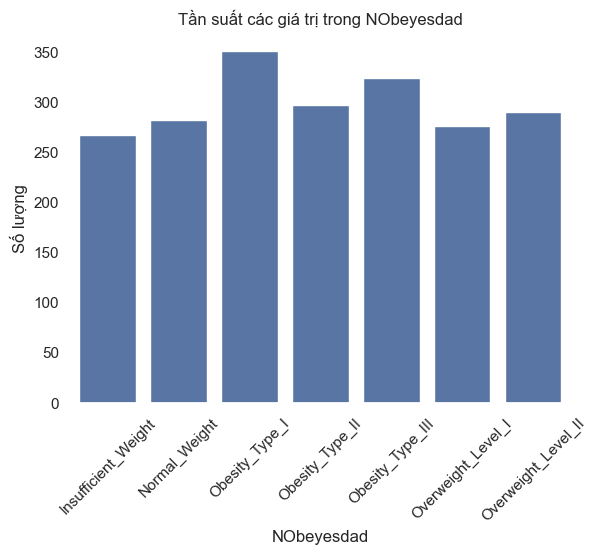

In [115]:
for col in categorical_cols:
    plt.figure()
    sns.countplot(x=data[col])
    plt.title(f"Tần suất các giá trị trong {col}")
    plt.xlabel(col)
    plt.ylabel("Số lượng")
    plt.xticks(rotation=45)
    plt.show()

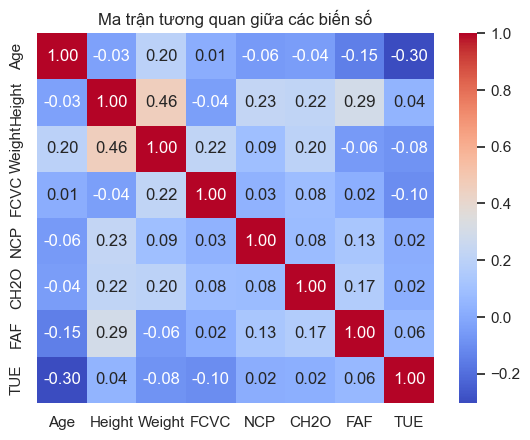

In [116]:
plt.figure()
corr_matrix = data[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Ma trận tương quan giữa các biến số")
plt.show()

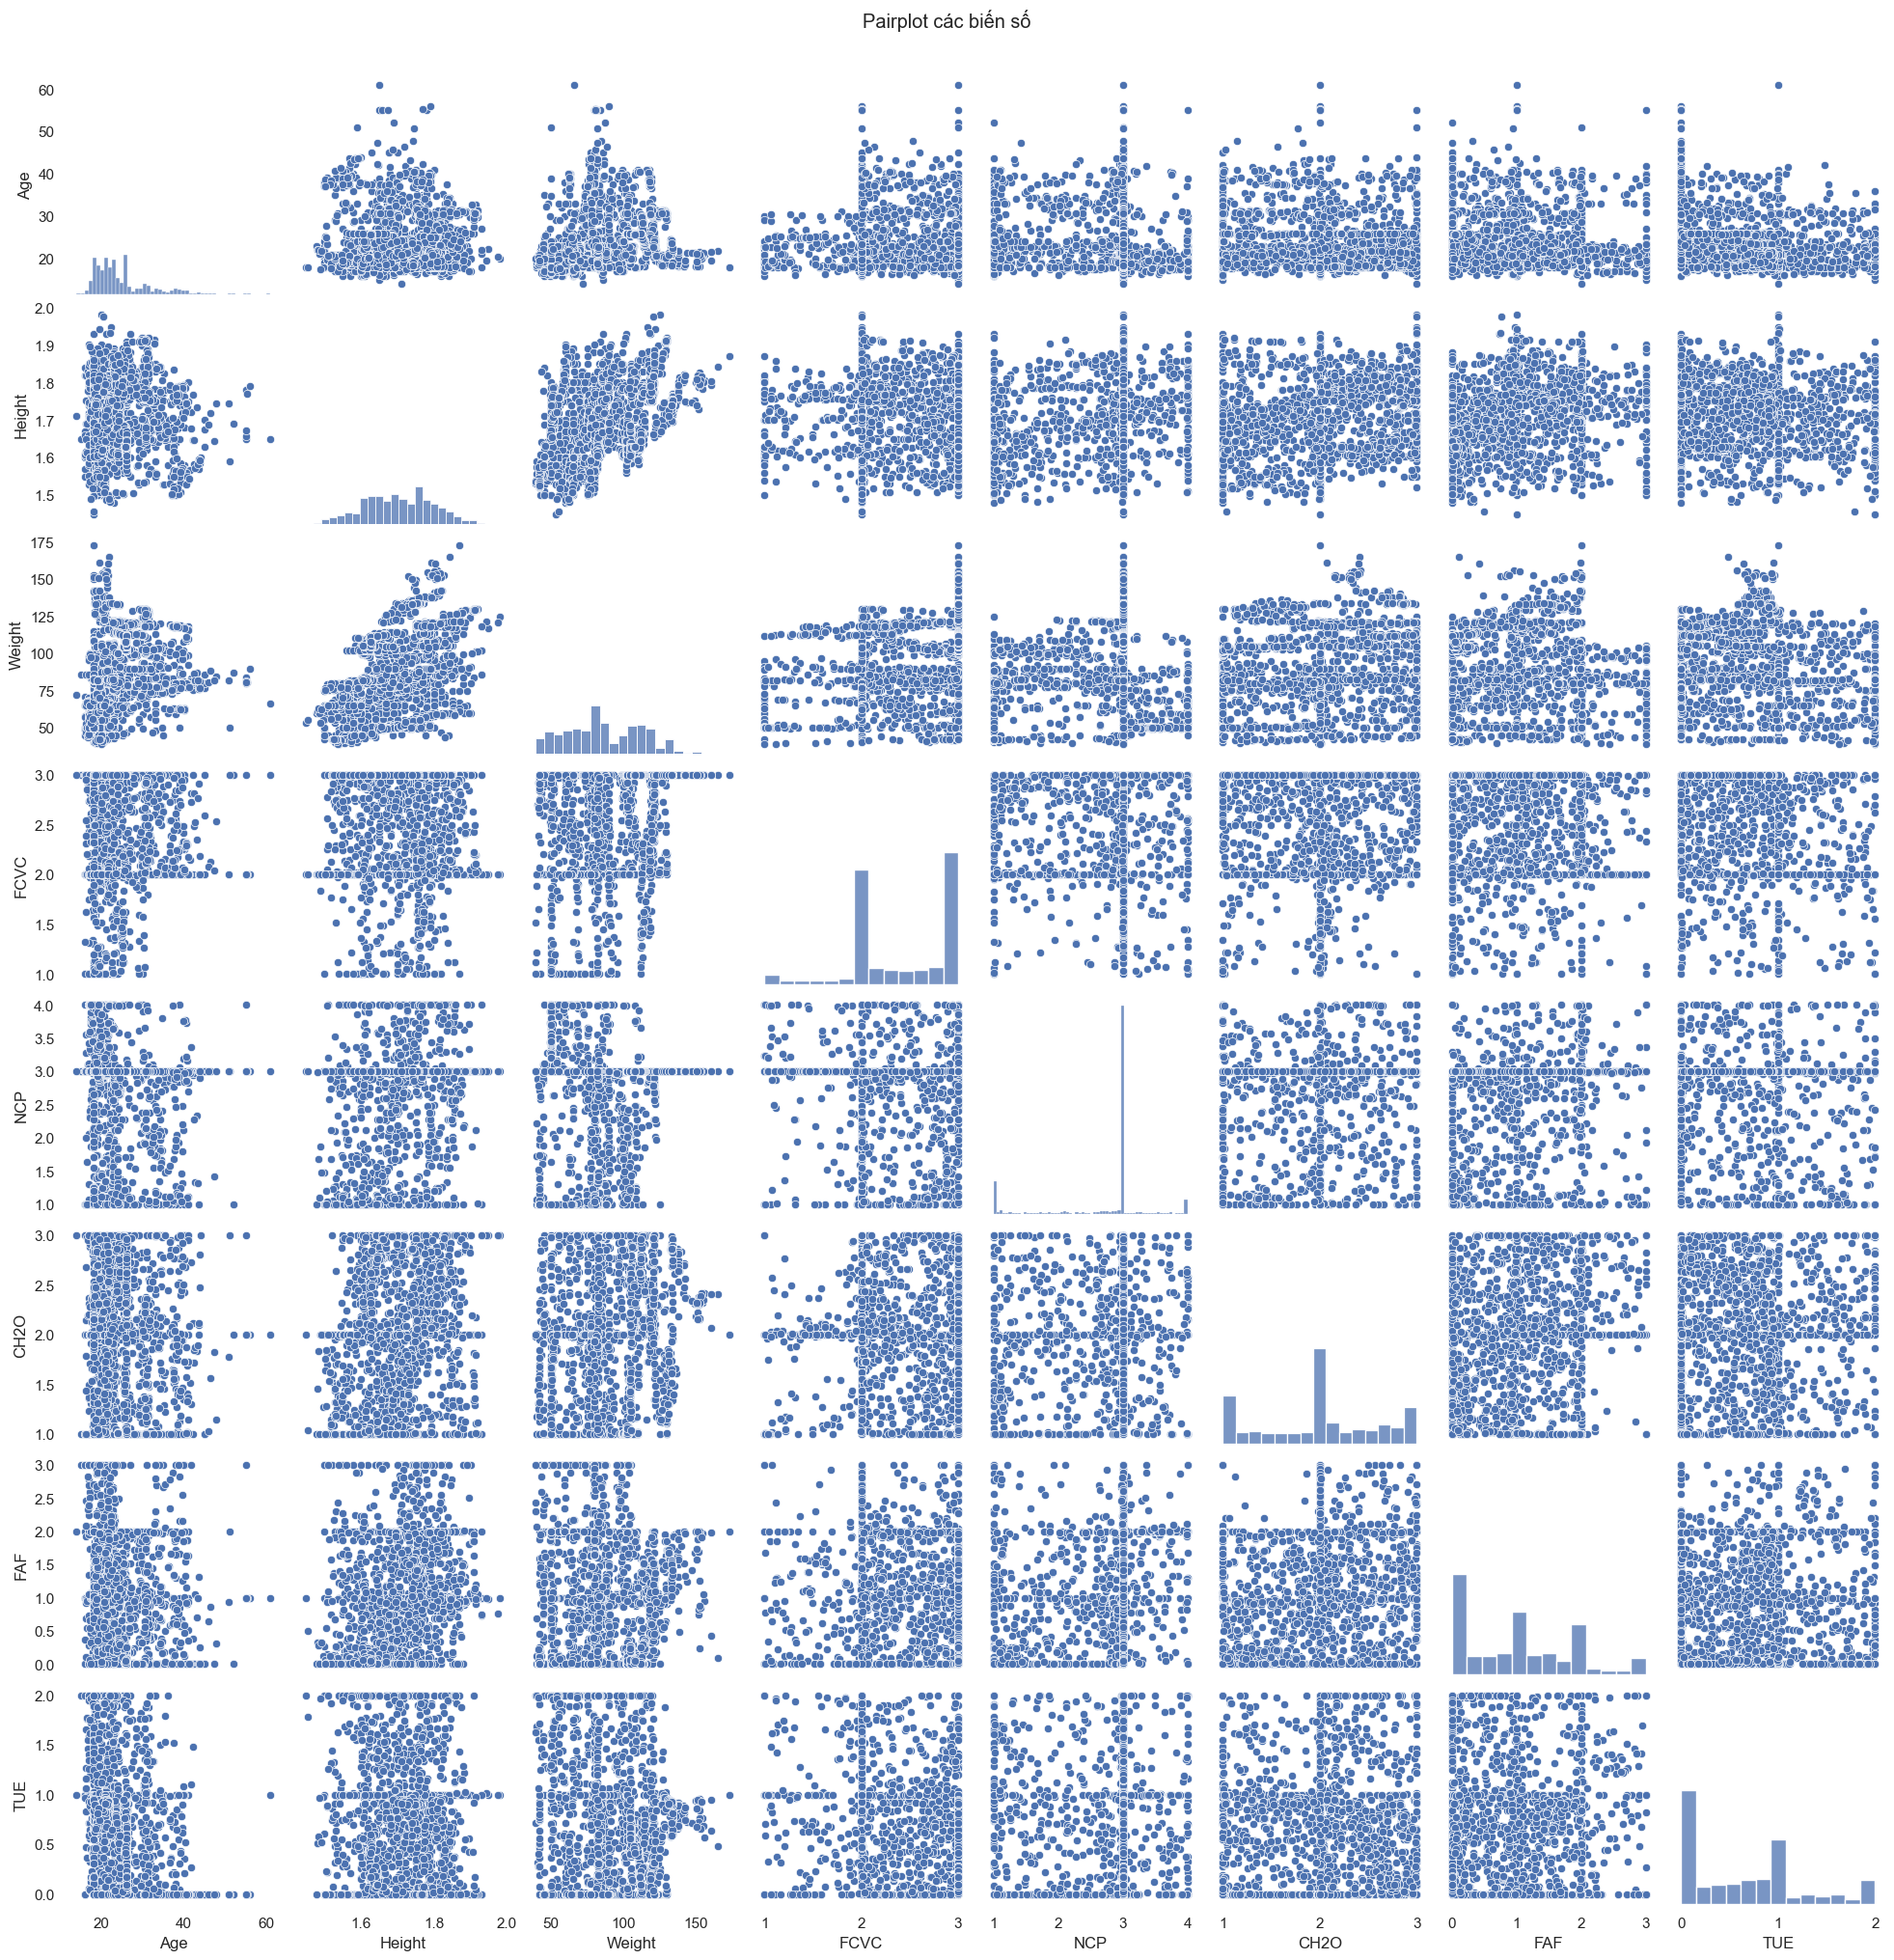

In [117]:
sns.pairplot(data[numerical_cols])
plt.suptitle("Pairplot các biến số", y=1.02)
plt.show()

### Normalize and Convert data

In [118]:
target_col = 'NObeyesdad'
y = data[target_col]
X = data.drop(target_col, axis=1)

X_encoded = pd.get_dummies(X, drop_first=True)

le = LabelEncoder()
y_encoded = le.fit_transform(y)

scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# In thông tin kích thước của tập dữ liệu
print("Kích thước tập huấn luyện:", X_train.shape, y_train.shape)
print("Kích thước tập kiểm tra:", X_test.shape, y_test.shape)

Kích thước tập huấn luyện: (1669, 23) (1669,)
Kích thước tập kiểm tra: (418, 23) (418,)


### Train


--- Logistic Regression ---
Accuracy: 0.8588516746411483
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.92      0.89        59
           1       0.83      0.74      0.78        61
           2       0.91      0.89      0.90        70
           3       0.97      1.00      0.98        64
           4       0.98      1.00      0.99        60
           5       0.73      0.65      0.69        55
           6       0.66      0.78      0.71        49

    accuracy                           0.86       418
   macro avg       0.85      0.85      0.85       418
weighted avg       0.86      0.86      0.86       418



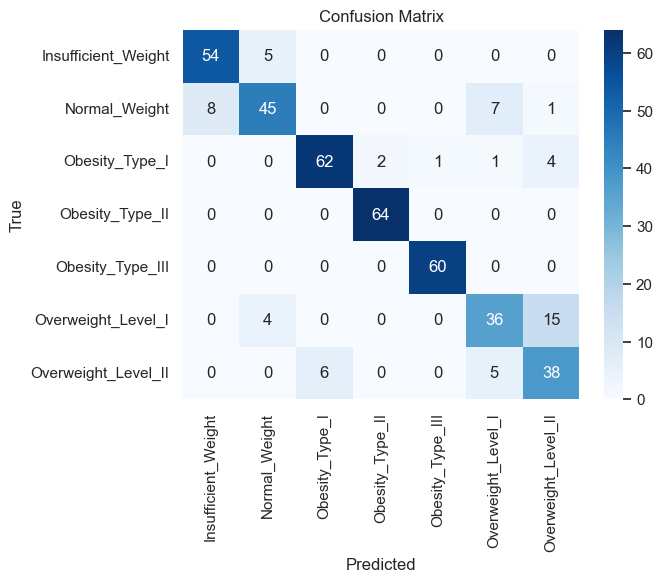


--- Decision Tree ---
Accuracy: 0.9138755980861244
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.98      0.92        59
           1       0.88      0.69      0.77        61
           2       0.93      0.96      0.94        70
           3       1.00      0.97      0.98        64
           4       0.98      1.00      0.99        60
           5       0.82      0.84      0.83        55
           6       0.90      0.96      0.93        49

    accuracy                           0.91       418
   macro avg       0.91      0.91      0.91       418
weighted avg       0.91      0.91      0.91       418



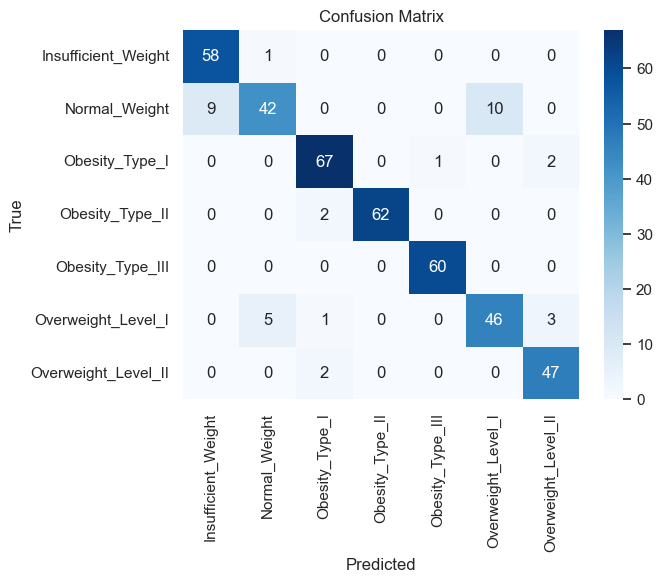


--- Random Forest ---
Accuracy: 0.9545454545454546
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.90      0.95        59
           1       0.81      0.95      0.87        61
           2       1.00      0.97      0.99        70
           3       1.00      1.00      1.00        64
           4       1.00      1.00      1.00        60
           5       0.94      0.89      0.92        55
           6       0.96      0.96      0.96        49

    accuracy                           0.95       418
   macro avg       0.96      0.95      0.95       418
weighted avg       0.96      0.95      0.96       418



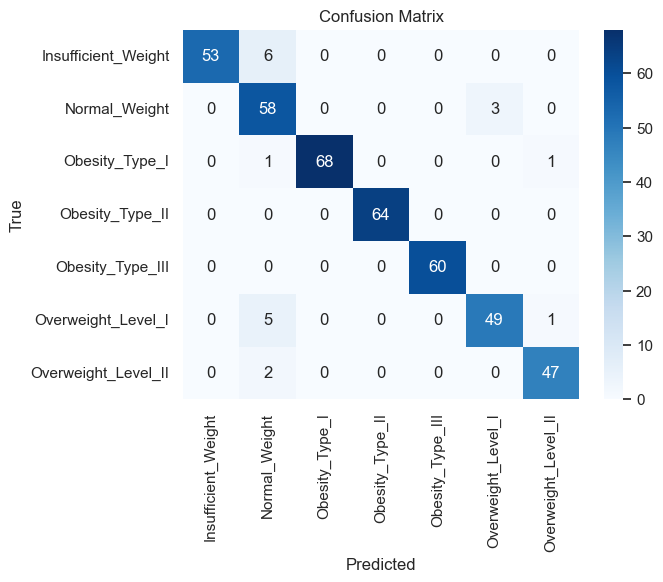


--- SVM ---
Accuracy: 0.8660287081339713
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.85      0.88        59
           1       0.63      0.72      0.67        61
           2       0.93      0.96      0.94        70
           3       0.98      0.97      0.98        64
           4       1.00      1.00      1.00        60
           5       0.78      0.76      0.77        55
           6       0.84      0.76      0.80        49

    accuracy                           0.87       418
   macro avg       0.87      0.86      0.86       418
weighted avg       0.87      0.87      0.87       418



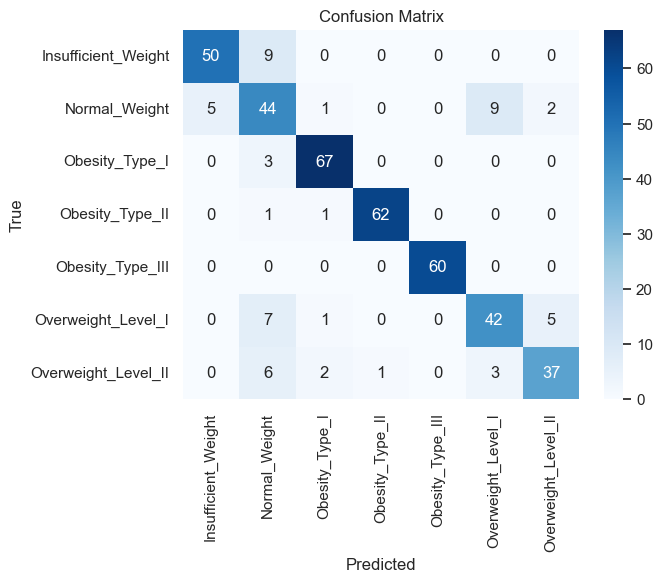


--- K-Nearest Neighbors ---
Accuracy: 0.80622009569378
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.86      0.81        59
           1       0.56      0.41      0.47        61
           2       0.76      0.90      0.82        70
           3       0.90      0.97      0.93        64
           4       1.00      1.00      1.00        60
           5       0.81      0.71      0.76        55
           6       0.80      0.76      0.78        49

    accuracy                           0.81       418
   macro avg       0.80      0.80      0.80       418
weighted avg       0.80      0.81      0.80       418



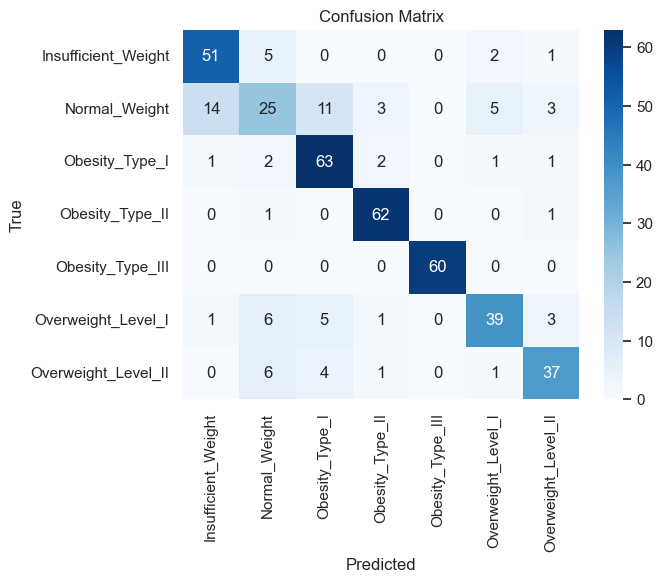

In [119]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier()
}


for model_name, model in models.items():
    print("\n---", model_name, "---")
    # Huấn luyện
    model.fit(X_train, y_train)
    # Dự đoán trên tập test
    y_pred = model.predict(X_test)
    # Tính accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print("Accuracy:", accuracy)
    # In báo cáo phân lớp
    print("Classification Report:\n", classification_report(y_test, y_pred))
    # In ra confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

### Handling overfitting

In [120]:
baseline_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    baseline_results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'report': classification_report(y_test, y_pred, output_dict=True)
    }

### Train with above method

In [121]:
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1','l2'],
    'solver': ['liblinear']
}

param_grid_dt = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy']
}

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']   # loại bỏ 'auto'
}

param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1]
}

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# grid for Logistic Regression
grid_lr = GridSearchCV(LogisticRegression(random_state=42),
                       param_grid, cv=5, scoring='accuracy')
grid_lr.fit(X_train, y_train)
print("Best LR params:", grid_lr.best_params_)

# Decision Tree
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42),
                       param_grid_dt, cv=5, scoring='accuracy')
grid_dt.fit(X_train, y_train)
print("Best DT params:", grid_dt.best_params_)

# Random Forest
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42),
                       param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train, y_train)
print("Best RF params:", grid_rf.best_params_)


# SVM
grid_svm = GridSearchCV(SVC(random_state=42),
                        param_grid_svm, cv=5, scoring='accuracy', n_jobs=-1)
grid_svm.fit(X_train, y_train)
print("Best SVM params:", grid_svm.best_params_)

# KNN
grid_knn = GridSearchCV(KNeighborsClassifier(),
                        param_grid_knn, cv=5, scoring='accuracy', n_jobs=-1)
grid_knn.fit(X_train, y_train)
print("Best KNN params:", grid_knn.best_params_)

Best LR params: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Best DT params: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best RF params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best SVM params: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Best KNN params: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}


In [123]:
models_tuned = {
    'Logistic Regression': LogisticRegression(penalty='l1', C=10, solver='liblinear', random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(max_depth=None, criterion='entropy', min_samples_leaf=1, min_samples_split=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=None, max_features='sqrt', min_samples_leaf=1, min_samples_split=5, random_state=42),
    'SVM': SVC(C=10, kernel='linear', gamma='scale', random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(metric='manhattan', n_neighbors=3, weights='distance')
}

tuned_results = {}

for name, model in models_tuned.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    tuned_results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'report': classification_report(y_test, y_pred, output_dict=True)
    }


### Compare

In [125]:
compare = []
for name in baseline_results:
    compare.append({
        'Model': name,
        'Baseline Accuracy': baseline_results[name]['accuracy'],
        'Tuned Accuracy': tuned_results[name]['accuracy']
    })
df_compare = pd.DataFrame(compare)
print(df_compare)

                 Model  Baseline Accuracy  Tuned Accuracy
0  Logistic Regression           0.858852        0.777512
1        Decision Tree           0.913876        0.959330
2        Random Forest           0.954545        0.942584
3                  SVM           0.866029        0.971292
4  K-Nearest Neighbors           0.806220        0.842105
